#Uploading Data
In the following section all the data being used for the regressional analysis is uploaded:

(1) Genomics of Drug Sensitivity in Cancer Database

An open-access resource provides comprehensive drug response data across hundreds of cell lines. The data from this source is in the CSV files, "Cytarabine_AML_data" and "Cytarabine_GDSC1_data" that is used for the polynomial regressions.

(2) PubMed Central

The specific stufy used from this an open-access resource was "RNA expression of genes involved in cytarabine metabolism and transport predicts cytarabine response in acute myeloid leukemia" which is used for the Multiple Regression Analysis and the logistic regresion.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Cytarabine_AML_data.csv to Cytarabine_AML_data.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Cytarabine_GDSC1_data.csv to Cytarabine_GDSC1_data.csv


In [3]:
from google.colab import files
uploaded = files.upload()

Saving AML_Cytarabine_Biomarkers.csv to AML_Cytarabine_Biomarkers.csv


#Assessing the Chemosensitivity of Cytarabine

The next two graphs showcase the chemosensitivity measured as a metric of resistance of both AML and general cancers in polynomial regressions. The rationale for this is to mitigate error from the narrow nature of the research samples found (n= 29) of cytarabine in AML.

The graphs plot the variables of area under the curve (AUC) and ln(IC50) against eachother, to asses resistance.

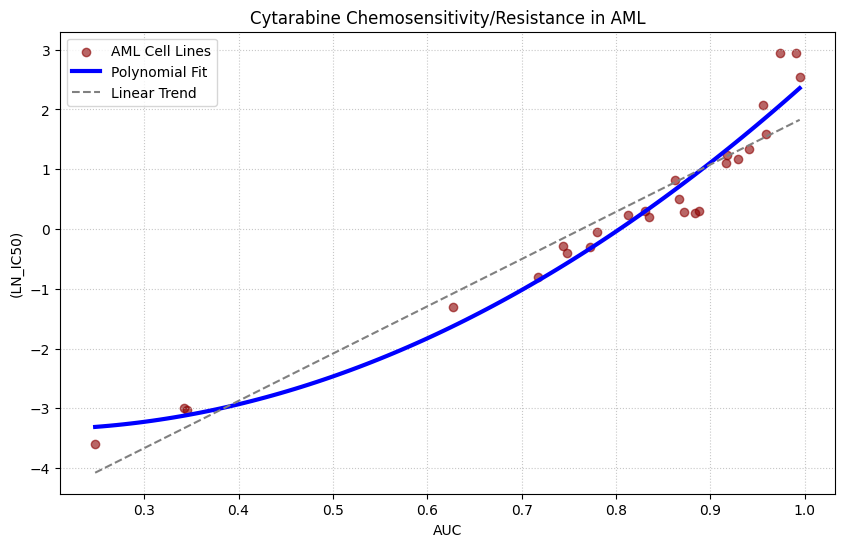


 FINAL MODEL EVALUATION
Mean Squared Error:        0.1232
R-squared:                 0.9540
T-test:                    4.04e-04
Regression Slope p-value:  5.65e-14


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats

#linking/prompting the use of the relevant dataset
df = pd.read_csv('Cytarabine_AML_data.csv').dropna(subset=['AUC', 'LN_IC50'])
X = df[['AUC']].values
y = df['LN_IC50'].values

# t-test
threshold = np.median(y)
sensitive_grp = df[df['LN_IC50'] < threshold]['AUC']
resistant_grp = df[df['LN_IC50'] >= threshold]['AUC']

# statistical tests
t_stat, p_val_ttest = stats.ttest_ind(sensitive_grp, resistant_grp)
slope, intercept, r_value, p_val_slope, std_err = stats.linregress(df['AUC'], df['LN_IC50'])

# polynomial creation (degree 2)
poly_feat = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_feat.fit_transform(X)
poly_model = LinearRegression().fit(X_poly, y)
y_poly_pred = poly_model.predict(X_poly)

# linear model
lin_model = LinearRegression().fit(X, y)

# creating graph
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='darkred', alpha=0.6, label='AML Cell Lines')

#smooth line output
X_smooth = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_smooth_poly = poly_feat.transform(X_smooth)

# fitting
plt.plot(X_smooth, poly_model.predict(X_smooth_poly), color='blue', linewidth=3, label='Polynomial Fit')
plt.plot(X_smooth, lin_model.predict(X_smooth), color='gray', linestyle='--', label='Linear Trend')

#labelling
plt.title('Cytarabine Chemosensitivity/Resistance in AML')
plt.xlabel('AUC')
plt.ylabel('(LN_IC50)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# summary (statistical evaluation) table
print("\n" + "="*25)
print(" FINAL MODEL EVALUATION")
print("="*25)
print(f"Mean Squared Error:        {mean_squared_error(y, y_poly_pred):.4f}")
print(f"R-squared:                 {r2_score(y, y_poly_pred):.4f}")
print(f"T-test:                    {p_val_ttest:.2e}")
print(f"Regression Slope p-value:  {p_val_slope:.2e}")


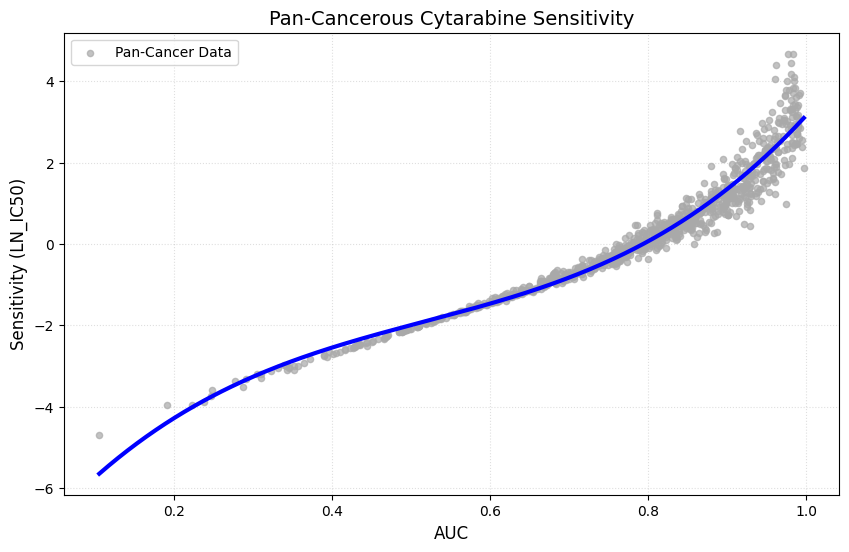


 FINAL MODEL EVALUATION
Mean Squared Error:   0.1204
R-squared:            0.9514
T-test:               4.04e-04 
Statistical P-value:  0.00e+00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

#linking/prompting the use of the relevant dataset
df = pd.read_csv('Cytarabine_GDSC1_data.csv').dropna(subset=['AUC', 'LN_IC50'])
X = df[['AUC']].values
y = df['LN_IC50'].values

# degree 3 polynomial
poly_feat = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_feat.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)

# Evaluation Metrics for the Full Set
y_pred = model.predict(X_poly)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

# statistical Significance (P-value)
slope, intercept, r_val, p_val, std_err = stats.linregress(df['AUC'], df['LN_IC50'])

# creating the graph
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='darkgrey', alpha=0.7, s=20, label='Pan-Cancer Data')

X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_smooth = model.predict(poly_feat.transform(X_range))
plt.plot(X_range, y_smooth, color='blue', linewidth=3 )

plt.title('Pan-Cancerous Cytarabine Sensitivity', fontsize=14)
plt.xlabel('AUC', fontsize=12)
plt.ylabel('Sensitivity (LN_IC50)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()

# summary (statistic evaluation) table
print("\n" + "="*25)
print(" FINAL MODEL EVALUATION")
print("="*25)
print(f"Mean Squared Error:   {mse:.4f}")
print(f"R-squared:            {r2:.4f}")
print(f"T-test:               {p_val_ttest:.2e} ")
print(f"Statistical P-value:  {p_val:.2e}")



#Assessing Cytarabine Biomarkers

The next two regression analyses the effects of two biomarkers, deoxycytidine kinase (dCK) and SAM and HD domain-containing protein 1 (SAMHD1) in cytarabine resistance.

(1) A multiple regression showing both biomarkers plotted against Ln(IC50)

(2) A logistic surface regression showing the biomarker expression in relation to predicting cytarabine resistance.

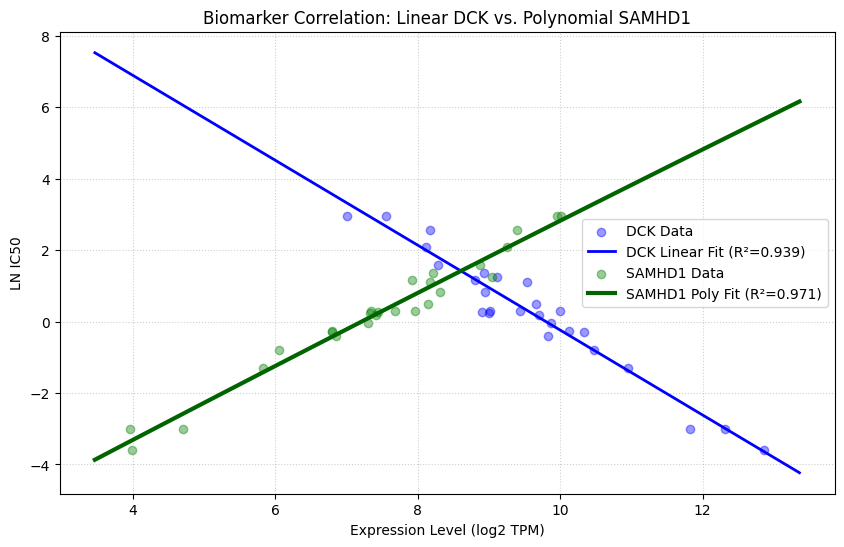


     DETAILED P-VALUE ANALYSIS
[BIOMARKER: DCK]
Linear Slope P-value: 4.10e-16

[BIOMARKER: SAMHD1]
Linear Term P-value:    4.30e-04
Overall Model P-value:  2.15e-18


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# linking data
df = pd.read_csv('AML_Cytarabine_Biomarkers.csv').dropna(subset=['LN_IC50', 'DCK_Expression', 'SAMHD1_Expression'])

y = df['LN_IC50'].values
X_dck = df[['DCK_Expression']].values
X_samhd1 = df[['SAMHD1_Expression']].values

# linear model for DCK
model_linear = LinearRegression().fit(X_dck, y)

# polynomial model for SAMHD1
poly_feat = PolynomialFeatures(degree=2, include_bias=True)
X_poly_samhd1 = poly_feat.fit_transform(X_samhd1)
model_poly = LinearRegression().fit(X_poly_samhd1, y)

# range for plotting
x_min = min(X_dck.min(), X_samhd1.min()) - 0.5
x_max = max(X_dck.max(), X_samhd1.max()) + 0.5
X_range = np.linspace(x_min, x_max, 100).reshape(-1, 1)

# predicting lines
y_line_linear = model_linear.predict(X_range)
y_line_poly = model_poly.predict(poly_feat.transform(X_range))

#plotting
plt.figure(figsize=(10, 6))

# DCK Plotting (Linear)
plt.scatter(X_dck, y, color='blue', alpha=0.4, label='DCK Data')
plt.plot(X_range, y_line_linear, color='blue', linewidth=2,
         label=f'DCK Linear Fit (R²={model_linear.score(X_dck, y):.3f})')

# SAMHD1 Plotting (Polynomial Curve)
plt.scatter(X_samhd1, y, color='green', alpha=0.4, label='SAMHD1 Data')
plt.plot(X_range, y_line_poly, color='darkgreen', linewidth=3,
         label=f'SAMHD1 Poly Fit (R²={model_poly.score(X_poly_samhd1, y):.3f})')

# lavels
plt.title('Biomarker Correlation: Linear DCK vs. Polynomial SAMHD1')
plt.xlabel('Expression Level (log2 TPM)')
plt.ylabel('LN IC50')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# statistical p value
print("     DETAILED P-VALUE ANALYSIS")
print("="*35)

# DCK Statistical Test (Linear)
X_dck_stat = sm.add_constant(X_dck)
res_dck = sm.OLS(y, X_dck_stat).fit()
print(f"[BIOMARKER: DCK]")
print(f"Linear Slope P-value: {res_dck.pvalues[1]:.2e}")

# SAMHD1 Statistical Test (Polynomial)
res_sam = sm.OLS(y, X_poly_samhd1).fit()
print(f"\n[BIOMARKER: SAMHD1]")
print(f"Linear Term P-value:    {res_sam.pvalues[1]:.2e}")
print(f"Overall Model P-value:  {res_sam.f_pvalue:.2e}")


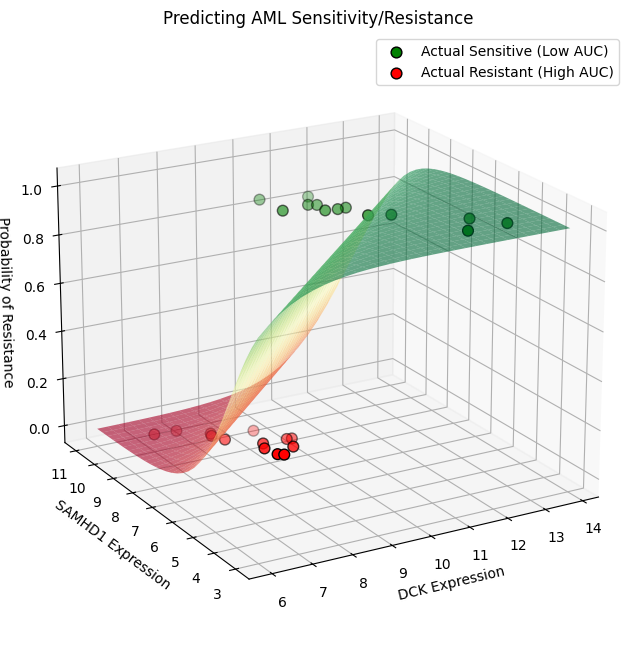

Model Intercept: -1.8220
DCK Weight: 1.0855
SAMHD1 Weight: -1.1004

 FINAL MODEL EVALUATION

[Likelihood Ratio Test]
G² = 19.8996, df = 2, p = 0.000048 ***

[Wald Test]
Intercept    coef=-1.8220  z=-0.105  p=0.91648  (ns)
DCK          coef=1.0855  z=0.892  p=0.37224  (ns)
SAMHD1       coef=-1.1004  z=-1.078  p=0.28118  (ns)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import log_loss
from scipy import stats

# loadig the relevant data
df = pd.read_csv('AML_Cytarabine_Biomarkers.csv')
median_auc = df['AUC'].median()
df['Is_Sensitive'] = (df['AUC'] < median_auc).astype(int)

# setting variables
X = df[['DCK_Expression', 'SAMHD1_Expression']].values
y = df['Is_Sensitive'].values

# fitting variables
model = LogisticRegression()
model.fit(X, y)

# grid for surface
x_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 30)
y_range = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 30)
xx, yy = np.meshgrid(x_range, y_range)

# creating sigmoid surface/calculating probability
probs = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
zz = probs.reshape(xx.shape)

# plotting the graph and surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xx, yy, zz, cmap='RdYlGn', alpha=0.6, antialiased=True)

# plotting actual data points (points at Z=1 are Sensitive, Z=0 are Resistant)
ax.scatter(X[y==1, 0], X[y==1, 1], 1, color='green', s=60, label='Actual Sensitive (Low AUC)', edgecolors='k')
ax.scatter(X[y==0, 0], X[y==0, 1], 0, color='red', s=60, label='Actual Resistant (High AUC)', edgecolors='k')

# labelling
ax.set_xlabel('DCK Expression')
ax.set_ylabel('SAMHD1 Expression ')
ax.set_zlabel('Probability of Resistance')
ax.set_title('Predicting AML Sensitivity/Resistance')
ax.view_init(elev=20, azim=-120) # Adjust view to see the S-curve clearly
plt.legend()
plt.show()

# equation parameters for model (included because its complex and beneficial for further analysis)
print(f"Model Intercept: {model.intercept_[0]:.4f}")
print(f"DCK Weight: {model.coef_[0][0]:.4f}")
print(f"SAMHD1 Weight: {model.coef_[0][1]:.4f}")


# performing tests for statistical evaluation
n, k = len(y), X.shape[1]

# setting the null model(intercept only)
null_model = LogisticRegression()
null_model.fit(np.zeros((n, 1)), y)

ll_full = -log_loss(y, model.predict_proba(X), normalize=False)
ll_null = -log_loss(y, null_model.predict_proba(np.zeros((n, 1))), normalize=False)

# Test 1: Likelihood Ratio Test
G2    = 2 * (ll_full - ll_null)
lrt_p = stats.chi2.sf(G2, df=k)
print("\n" + "="*25)
print(" FINAL MODEL EVALUATION")
print("="*25)
print(f"\n[Likelihood Ratio Test]")
print(f"G² = {G2:.4f}, df = {k}, p = {lrt_p:.6f}", "***" if lrt_p < 0.001 else ("**" if lrt_p < 0.01 else ("*" if lrt_p < 0.05 else "(ns)")))

# Test 2: Wald Test
probs    = model.predict_proba(X)[:, 1]
X_design = np.column_stack([np.ones(n), X])
W        = probs * (1 - probs)
se       = np.sqrt(np.diag(np.linalg.inv(X_design.T @ (W[:, None] * X_design))))
coefs    = np.concatenate([model.intercept_, model.coef_[0]])
z        = coefs / se
p_wald   = 2 * stats.norm.sf(np.abs(z))

print(f"\n[Wald Test]")
for name, c, zv, pv in zip(['Intercept','DCK','SAMHD1'], coefs, z, p_wald):
    sig = "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else "(ns)"))
    print(f"{name:<12} coef={c:.4f}  z={zv:.3f}  p={pv:.5f}  {sig}")

